========== HOUSE PRICE DATASET ==========
    Area  Bedrooms  Bathrooms  Age  Parking     Price
0   1000         2          1   20        0   2500000
1   1200         2          2   15        1   3200000
2   1500         3          2   10        1   4500000
3   1800         3          2    8        1   5200000
4   2000         3          3    5        2   6000000
5   2200         4          3    7        2   6800000
6   2500         4          3    4        2   7500000
7   2800         4          4    3        2   8500000
8   3000         5          4    2        2   9500000
9   3500         5          4    1        3  11500000
10  1100         2          1   18        0   2800000
11  1300         3          2   12        1   3800000
12  1600         3          2    9        1   4700000
13  1900         3          3    6        1   5500000
14  2100         4          3    5        2   6500000
15  2300         4          3    4        2   7200000
16  2600         4          4    3      

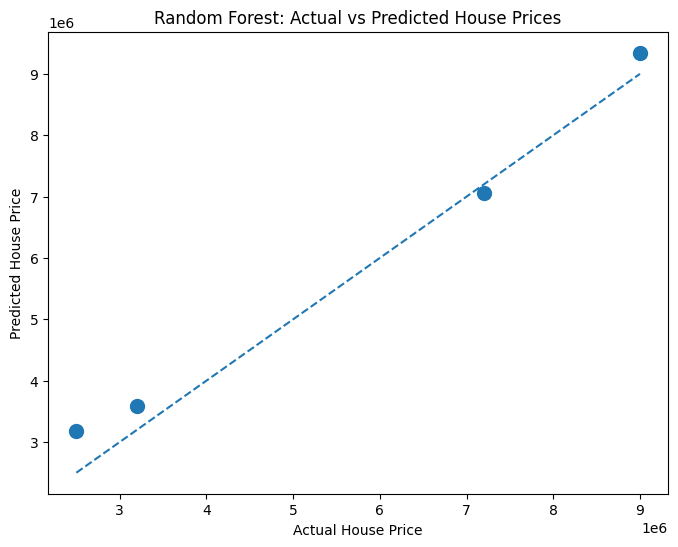

In [8]:
# ============================================================
# HOUSE PRICE PREDICTION USING RANDOM FOREST REGRESSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. CREATE DATASET
# ============================================================

data = {
    "Area": [
        1000, 1200, 1500, 1800, 2000,
        2200, 2500, 2800, 3000, 3500,
        1100, 1300, 1600, 1900, 2100,
        2300, 2600, 2900, 3200, 4000
    ],

    "Bedrooms": [
        2, 2, 3, 3, 3,
        4, 4, 4, 5, 5,
        2, 3, 3, 3, 4,
        4, 4, 5, 5, 6
    ],

    "Bathrooms": [
        1, 2, 2, 2, 3,
        3, 3, 4, 4, 4,
        1, 2, 2, 3, 3,
        3, 4, 4, 5, 5
    ],

    "Age": [
        20, 15, 10, 8, 5,
        7, 4, 3, 2, 1,
        18, 12, 9, 6, 5,
        4, 3, 2, 1, 1
    ],

    "Parking": [
        0, 1, 1, 1, 2,
        2, 2, 2, 2, 3,
        0, 1, 1, 1, 2,
        2, 2, 2, 3, 3
    ],

    "Price": [
        2500000, 3200000, 4500000, 5200000, 6000000,
        6800000, 7500000, 8500000, 9500000, 11500000,
        2800000, 3800000, 4700000, 5500000, 6500000,
        7200000, 8000000, 9000000, 10500000, 13500000
    ]
}

df = pd.DataFrame(data)


# ============================================================
# 2. DISPLAY DATASET
# ============================================================

print("========== HOUSE PRICE DATASET ==========")
print(df)

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())


# ============================================================
# 4. SELECT FEATURES AND TARGET
# ============================================================

X = df.drop("Price", axis=1)
y = df["Price"]


# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 6. CREATE RANDOM FOREST MODEL
# ============================================================

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)


# ============================================================
# 7. TRAIN MODEL
# ============================================================

model.fit(X_train, y_train)

print("\nModel Training Completed!")


# ============================================================
# 8. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 9. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))


# ============================================================
# 10. ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.round(2)
})

print("\n========== ACTUAL VS PREDICTED ==========")
print(comparison)


# ============================================================
# 11. PREDICT PRICE OF A NEW HOUSE
# ============================================================

new_house = pd.DataFrame({
    "Area": [2000],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "Age": [5],
    "Parking": [2]
})

predicted_price = model.predict(new_house)

print("\n========== NEW HOUSE PREDICTION ==========")

print("House Details:")
print(new_house)

print(
    "\nPredicted House Price: ₹",
    f"{predicted_price[0]:,.2f}"
)


# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========")
print(importance)


# ============================================================
# 13. VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    s=100
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Random Forest: Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()